In [3]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00


In [4]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3f87bdf6660fdd47a85c318f950c958f05b6ce28892534f3dfdf3991309c0526
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [34]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt
import matplotlib.pyplot as plt
from scipy.stats import entropy
import ta
from sklearn.neighbors import NearestNeighbors

In [47]:
def series_from(feature_string, _close, _high, _low, _hlc3, f_paramA, f_paramB=None):
    """
    Generate a feature based on the provided feature string and parameters.

    :param feature_string: The technical indicator to compute (e.g., "RSI", "WT", "CCI", "ADX").
    :param _close: Series of closing prices.
    :param _high: Series of high prices.
    :param _low: Series of low prices.
    :param _hlc3: Series of typical prices (HLC3).
    :param f_paramA: Primary parameter for the indicator.
    :param f_paramB: Optional secondary parameter for the indicator.
    :return: Computed feature series.
    """
    if feature_string == "RSI":
        return ta.momentum.RSIIndicator(close=_close, window=f_paramA).rsi()
    elif feature_string == "WT":
        return ta.trend.WMAIndicator(close=_hlc3, window=f_paramA).wma()
    elif feature_string == "CCI":
        return ta.trend.CCIIndicator(high=_high, low=_low, close=_close, window=f_paramA).cci()
    elif feature_string == "ADX":
        return ta.trend.ADXIndicator(high=_high, low=_low, close=_close, window=f_paramA).adx()
    else:
        raise ValueError(f"Feature {feature_string} is not recognized.")

# Fetch AAPL stock data
ticker_symbol = "AAPL"
start_date = "2016-10-01"
end_date = "2024-10-01"
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Calculate HLC3 for WaveTrend
stock_data['HLC3'] = (stock_data['High'] + stock_data['Low'] + stock_data['Close']) / 3

f_paramA = 14
f_paramB = None

# Add different features to the stock data DataFrame using `series_from`
stock_data['RSI'] = series_from("RSI", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['WT'] = series_from("WT", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['CCI'] = series_from("CCI", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['ADX'] = series_from("ADX", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)

print(stock_data[['RSI', 'WT', 'CCI', 'ADX']].tail())

[*********************100%***********************]  1 of 1 completed


                  RSI          WT         CCI        ADX
Date                                                    
2024-09-24  57.294586  223.581587  100.570182  14.887306
2024-09-25  55.370138  224.038317   60.607715  14.332929
2024-09-26  57.152532  224.635365   71.102018  14.053100
2024-09-27  57.580854  225.324222   76.359874  13.992587
2024-09-30  64.877271  226.422095  118.381944  14.573083


# CUSUM breakpoints

[*********************100%***********************]  1 of 1 completed


Structural Break
0    2003
1       8
Name: count, dtype: int64


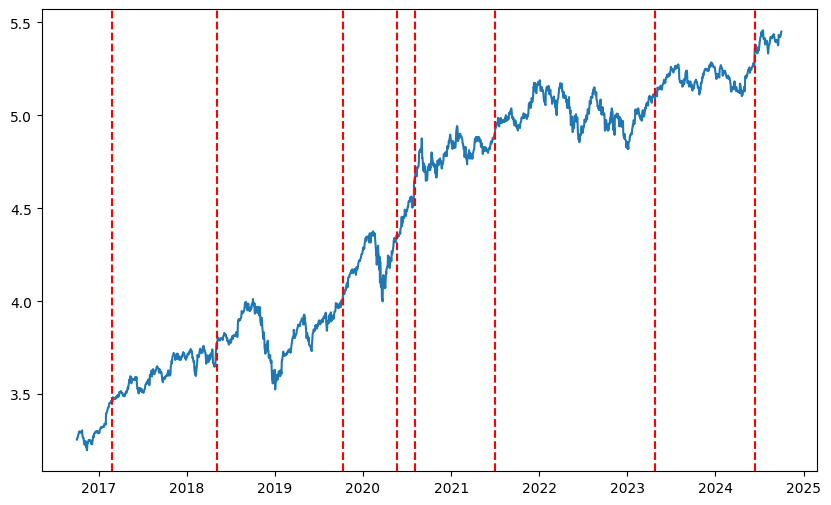

In [48]:
def apply_cusum(series, threshold=0.03):
    """Simple CUSUM implementation for detecting structural breaks."""
    mean_value = series.mean()
    cumulative_sum = 0
    cusum_signal = []
    for price in series:
        cumulative_sum += price - mean_value
        if abs(cumulative_sum) > threshold:
            cusum_signal.append(1)
            cumulative_sum = 0
        else:
            cusum_signal.append(0)
    return cusum_signal

# fetch data
ticker_symbol = "AAPL"
start_date = "2016-10-01"
end_date = "2024-10-01"
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

stock_data['Log Stock Price'] = np.log(stock_data['Adj Close'])
stock_data['Log Returns'] = stock_data['Log Stock Price'].diff()

# Apply CUSUM to detect structural breaks
cusum_feature = apply_cusum(stock_data['Log Returns'].dropna(), threshold=0.03)  # Adjusted threshold maybe

stock_data['CUSUM Feature'] = pd.Series(cusum_feature, index=stock_data['Log Returns'].dropna().index)

# Reindex CUSUM feature
stock_data['CUSUM Feature'] = stock_data['CUSUM Feature'].reindex(stock_data.index, fill_value=0)

# Detect Structural Breaks using Ruptures
model = "l2"  # Least-squares method
algo = rpt.Pelt(model=model).fit(stock_data['Log Stock Price'].dropna().values)

### Use a lower penalty to detect more breakpoints
breakpoints = algo.predict(pen=2)

# Remove the last breakpoint
breakpoints = breakpoints[:-1]

stock_data['Structural Break'] = 0

# Mark the detected breakpoints
stock_data.iloc[breakpoints, stock_data.columns.get_loc('Structural Break')] = 1

print(stock_data['Structural Break'].value_counts())

plt.figure(figsize=(10, 6))
plt.plot(stock_data['Log Stock Price'], label="Log Stock Price")
for bp in breakpoints:
    plt.axvline(x=stock_data.index[bp], color='red', linestyle='--', label='Break Point')
plt.show()

## Structural Breaks Possible Alternative

In [37]:
# different penalty values
for pen_value in [0.5, 1, 2, 3, 4]:
    algo = rpt.Pelt(model="l2").fit(stock_data['Log Stock Price'].dropna().values)
    breakpoints = algo.predict(pen=pen_value)
    print(f"Breakpoints for penalty {pen_value}: {breakpoints}")

Breakpoints for penalty 0.5: [90, 270, 460, 535, 615, 735, 780, 920, 965, 1050, 1195, 1295, 1410, 1635, 1935, 2011]
Breakpoints for penalty 1: [90, 270, 460, 535, 615, 770, 920, 965, 1195, 1650, 1935, 2011]
Breakpoints for penalty 2: [100, 400, 760, 915, 965, 1195, 1650, 1935, 2011]
Breakpoints for penalty 3: [100, 400, 765, 945, 1195, 1660, 2011]
Breakpoints for penalty 4: [100, 400, 765, 945, 1195, 1660, 2011]


In [38]:
# different models
for model in ["l2", "l1", "rbf"]:
    algo = rpt.Pelt(model=model).fit(stock_data['Log Stock Price'].dropna().values)
    breakpoints = algo.predict(pen=3)
    print(f"Breakpoints for model {model}: {breakpoints}")

Breakpoints for model l2: [100, 400, 765, 945, 1195, 1660, 2011]
Breakpoints for model l1: [85, 145, 270, 400, 460, 535, 615, 760, 810, 925, 965, 1050, 1195, 1295, 1400, 1645, 1935, 2011]
Breakpoints for model rbf: [90, 270, 460, 535, 615, 770, 920, 965, 1195, 1650, 1935, 2011]


#  Supremum Augmented Dickey-Fuller

In [39]:
def rolling_sadf(series, window=60):
    sadf_values = []
    for i in range(len(series) - window + 1):
        sub_series = series.iloc[i:i + window]
        result = adfuller(sub_series)
        sadf_values.append(result[0])  # ADF statistic
    # Return NaNs for first (window - 1) values, followed by SADF values
    return [np.nan] * (window - 1) + sadf_values

# Apply rolling SADF test
window_size = 60
sadf_values = rolling_sadf(stock_data['Log Stock Price'].dropna(), window=window_size)

# Reindex
stock_data['SADF Feature'] = pd.Series(sadf_values, index=stock_data['Log Stock Price'].dropna().index)

In [40]:
stock_data[['Log Stock Price', 'Log Returns', 'SADF Feature', 'CUSUM Feature', 'Structural Break']].tail(20)

,Log Stock Price,Log Returns,SADF Feature,CUSUM Feature,Structural Break
Date,,,,,
2024-09-03,5.406140,-0.027582,-2.905236,0.0,0
2024-09-04,5.397484,-0.008656,-3.830359,1.0,0
2024-09-05,5.404388,0.006904,-2.262782,0.0,0
2024-09-06,5.397348,-0.007040,-1.909594,0.0,0
2024-09-09,5.397755,0.000407,-1.880344,0.0,0
2024-09-10,5.394127,-0.003628,-1.983743,0.0,0
2024-09-11,5.405646,0.011519,-1.811881,0.0,0
2024-09-12,5.406140,0.000494,-1.903205,0.0,0
2024-09-13,5.404927,-0.001213,-2.207914,0.0,0


In [41]:
def series_from(feature_string, _close, _high, _low, _hlc3, f_paramA, f_paramB=None):
    if feature_string == "RSI":
        return ta.momentum.RSIIndicator(close=_close, window=f_paramA).rsi()
    elif feature_string == "WT":
        return ta.trend.WMAIndicator(close=_hlc3, window=f_paramA).wma()
    elif feature_string == "CCI":
        return ta.trend.CCIIndicator(high=_high, low=_low, close=_close, window=f_paramA).cci()
    elif feature_string == "ADX":
        return ta.trend.ADXIndicator(high=_high, low=_low, close=_close, window=f_paramA).adx()
    else:
        raise ValueError(f"Feature {feature_string} is not recognized.")

# calculate Lorentzian distance between two vectors
def lorentzian_distance(x, y):
    return np.sum(np.log(1 + np.abs(x - y)))

# get nearest neighbors using Lorentzian distance
def get_nearest_neighbors(X, n_neighbors=5):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=lorentzian_distance)
    nbrs.fit(X)
    return nbrs

# Lorentzian Classifier
def apply_lorentzian_classifier(stock_data, feature_columns, neighbors_count=8):
    """
    Apply Lorentzian Distance Classifier to predict the direction of price movement.
    """
    # Extract feature values and drop rows with NaN
    X = stock_data[feature_columns].dropna().values
    stock_data_cleaned = stock_data.dropna(subset=feature_columns).copy()  # Remove rows with NaN values for features

    # if len(X) < neighbors_count:
    #     raise ValueError("Not enough data to find neighbors, adjust neighbors_count or check input data.")

    # Get nearest neighbors based on Lorentzian distance
    nbrs = get_nearest_neighbors(X, n_neighbors=neighbors_count)
    distances, indices = nbrs.kneighbors(X)

    # Simplified target variable: price movement based on the difference of the 'Close' price
    prediction = np.sign(np.diff(stock_data_cleaned['Close'].values))
    prediction = np.append(prediction, [np.nan])

    stock_data_cleaned['Prediction'] = prediction
    stock_data_cleaned['ANN_Prediction'] = np.nan

    # Take the majority vote from the nearest neighbors for each point
    for i in range(len(stock_data_cleaned) - neighbors_count):
        # Find the predictions of the nearest neighbors
        neighbor_votes = stock_data_cleaned['Prediction'].iloc[indices[i]]

        neighbor_votes = neighbor_votes.dropna()

        # If there are no valid neighbors, skip
        if len(neighbor_votes) == 0:
            continue

        # Get the majority vote
        stock_data_cleaned.iloc[i, stock_data_cleaned.columns.get_loc('ANN_Prediction')] = neighbor_votes.mode()[0]

    stock_data['Prediction'] = np.nan
    stock_data['ANN_Prediction'] = np.nan

    stock_data.loc[stock_data_cleaned.index, 'Prediction'] = stock_data_cleaned['Prediction']
    stock_data.loc[stock_data_cleaned.index, 'ANN_Prediction'] = stock_data_cleaned['ANN_Prediction']

    return stock_data

# Calculate HLC3
stock_data['HLC3'] = (stock_data['High'] + stock_data['Low'] + stock_data['Close']) / 3

f_paramA = 14
f_paramB = None

# Generate technical indicator features
stock_data['RSI'] = series_from("RSI", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['WT'] = series_from("WT", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['CCI'] = series_from("CCI", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)
stock_data['ADX'] = series_from("ADX", stock_data['Close'], stock_data['High'], stock_data['Low'], stock_data['HLC3'], f_paramA)

feature_columns = ['RSI', 'WT', 'CCI', 'ADX']

# Apply Lorentzian Classifier
stock_data = apply_lorentzian_classifier(stock_data, feature_columns, neighbors_count=8)

print(stock_data[['Close', 'RSI', 'WT', 'CCI', 'ADX', 'Prediction', 'ANN_Prediction']].tail(10))

                 Close        RSI          WT         CCI        ADX  \
Date                                                                   
2024-09-17  216.789993  40.125090  220.534064 -129.089439  15.848736   
2024-09-18  220.690002  48.256004  220.258858  -35.365778  15.314918   
2024-09-19  228.869995  60.402141  221.045271  147.898432  15.008615   
2024-09-20  228.199997  59.176860  222.106381  188.621883  15.241812   
2024-09-23  226.470001  56.017060  222.841936  117.745489  15.067182   
2024-09-24  227.369995  57.294586  223.581587  100.570182  14.887306   
2024-09-25  226.369995  55.370138  224.038317   60.607715  14.332929   
2024-09-26  227.520004  57.152532  224.635365   71.102018  14.053100   
2024-09-27  227.789993  57.580854  225.324222   76.359874  13.992587   
2024-09-30  233.000000  64.877271  226.422095  118.381944  14.573083   

            Prediction  ANN_Prediction  
Date                                    
2024-09-17         1.0             1.0  
2024-09-18  

In [42]:
print(stock_data[['Close', 'RSI', 'WT', 'CCI', 'ADX', 'Prediction', 'ANN_Prediction']].tail(20))

                 Close        RSI          WT         CCI        ADX  \
Date                                                                   
2024-09-03  222.770004  49.335903  226.853904  -79.720346  14.410228   
2024-09-04  220.850006  46.281729  226.042888 -244.858160  14.720168   
2024-09-05  222.380005  48.991593  225.657650 -108.687857  14.095046   
2024-09-06  220.820007  46.420304  225.125588 -123.719909  13.863651   
2024-09-09  220.910004  46.594445  224.319049 -151.677010  14.216403   
2024-09-10  220.110001  45.188462  223.538064 -123.132328  14.488419   
2024-09-11  222.660004  50.333013  223.059588  -70.457729  14.308790   
2024-09-12  222.770004  50.548635  222.742351  -45.570454  14.017778   
2024-09-13  222.500000  49.975128  222.561525  -24.296361  13.609733   
2024-09-16  216.320007  39.053414  221.482541 -152.460224  14.770697   
2024-09-17  216.789993  40.125090  220.534064 -129.089439  15.848736   
2024-09-18  220.690002  48.256004  220.258858  -35.365778  15.31

In [43]:
stock_data.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Log Stock Price', 'Log Returns', 'CUSUM Feature', 'Structural Break',
       'SADF Feature', 'HLC3', 'RSI', 'WT', 'CCI', 'ADX', 'Prediction',
       'ANN_Prediction'],
      dtype='object')

In [44]:
stock_data.head()

,Open,High,Low,Close,Adj Close,Volume,Log Stock Price,Log Returns,CUSUM Feature,Structural Break,SADF Feature,HLC3,RSI,WT,CCI,ADX,Prediction,ANN_Prediction
Date,,,,,,,,,,,,,,,,,,
2016-10-03,28.177500,28.262501,28.070000,28.129999,25.946959,86807200,3.256054,NaN,NaN,0,NaN,28.154167,NaN,NaN,NaN,0.0,NaN,NaN
2016-10-04,28.264999,28.577499,28.157499,28.250000,26.057644,118947200,3.260311,0.004257,0.0,0,NaN,28.328333,NaN,NaN,NaN,0.0,NaN,NaN
2016-10-05,28.350000,28.415001,28.172501,28.262501,26.069178,85812400,3.260754,0.000443,0.0,0,NaN,28.283334,NaN,NaN,NaN,0.0,NaN,NaN
2016-10-06,28.424999,28.584999,28.282499,28.472500,26.262880,115117200,3.268157,0.007403,0.0,0,NaN,28.446666,NaN,NaN,NaN,0.0,NaN,NaN
2016-10-07,28.577499,28.639999,28.377501,28.514999,26.302076,97433600,3.269648,0.001491,0.0,0,NaN,28.510833,NaN,NaN,NaN,0.0,NaN,NaN


In [46]:
stock_data.tail(30)

,Open,High,Low,Close,Adj Close,Volume,Log Stock Price,Log Returns,CUSUM Feature,Structural Break,SADF Feature,HLC3,RSI,WT,CCI,ADX,Prediction,ANN_Prediction
Date,,,,,,,,,,,,,,,,,,
2024-08-19,225.720001,225.990005,223.039993,225.889999,225.889999,40687800,5.420048,-0.000708,0.0,0,-2.040535,224.973333,60.464886,219.231207,87.740345,20.565372,1.0,1.0
2024-08-20,225.770004,227.169998,225.449997,226.509995,226.509995,30299000,5.422789,0.002741,0.0,0,-2.003662,226.376663,61.215104,220.394635,96.500912,19.430534,-1.0,-1.0
2024-08-21,226.520004,227.979996,225.050003,226.399994,226.399994,34765500,5.422303,-0.000486,0.0,0,-2.018718,226.476664,60.993956,221.531396,86.382591,18.542504,-1.0,-1.0
2024-08-22,227.789993,228.339996,223.899994,224.529999,224.529999,43695300,5.414009,-0.008294,0.0,0,-2.200835,225.589996,57.210163,222.487808,70.273334,17.443646,1.0,1.0
2024-08-23,225.660004,228.220001,224.330002,226.839996,226.839996,38677300,5.424245,0.010236,0.0,0,-2.198735,226.463333,60.472270,223.517491,72.863241,16.423277,1.0,1.0
2024-08-26,226.759995,227.279999,223.889999,227.179993,227.179993,30602200,5.425743,0.001498,0.0,0,-2.263608,226.116664,60.944214,224.308506,63.923356,15.360300,1.0,1.0
2024-08-27,226.000000,228.850006,224.889999,228.029999,228.029999,35934600,5.429477,0.003735,0.0,0,-2.229013,227.256668,62.160583,225.060856,75.081985,14.772764,-1.0,1.0
2024-08-28,227.919998,229.860001,225.679993,226.490005,226.490005,38052200,5.422701,-0.006776,0.0,0,-2.426607,227.343333,58.599706,225.659935,75.663402,14.478365,1.0,1.0
2024-08-29,230.100006,232.919998,228.880005,229.789993,229.789993,51906300,5.437166,0.014465,0.0,0,-2.344143,230.529999,63.433651,226.538856,157.590544,14.906775,-1.0,-1.0
